# Биоинформатика, второй год, второй семестр. ДЗ 2.

Выполнил Махлин Мирон

## Настройка окружения

In [ ]:
!wget https://github.com/conda-forge/miniforge/releases/download/24.11.3-0/Miniforge3-24.11.3-0-Linux-x86_64.sh

In [9]:
! bash Miniforge3-24.11.3-0-Linux-x86_64.sh -b -p $HOME/mambaforge

PREFIX=/home/ext.mmakhlin/mambaforge
Unpacking payload ...
Extracting _libgcc_mutex-0.1-conda_forge.tar.bz2
Extracting ca-certificates-2024.12.14-hbcca054_0.conda
Extracting ld_impl_linux-64-2.43-h712a8e2_2.conda
Extracting pybind11-abi-4-hd8ed1ab_3.tar.bz2
Extracting python_abi-3.12-5_cp312.conda
Extracting tzdata-2025a-h78e105d_0.conda
Extracting libgomp-14.2.0-h77fa898_1.conda
Extracting _openmp_mutex-4.5-2_gnu.tar.bz2
Extracting libgcc-14.2.0-h77fa898_1.conda
Extracting c-ares-1.34.4-hb9d3cd8_0.conda
Extracting libexpat-2.6.4-h5888daf_0.conda
Extracting libgcc-ng-14.2.0-h69a702a_1.conda
Extracting liblzma-5.6.3-hb9d3cd8_1.conda
Extracting libstdcxx-14.2.0-hc0a3c3a_1.conda
Extracting libzlib-1.3.1-hb9d3cd8_2.conda
Extracting ncurses-6.5-h2d0b736_2.conda
Extracting openssl-3.4.0-h7b32b05_1.conda
Extracting reproc-14.2.5.post0-hb9d3cd8_0.conda
Extracting bzip2-1.0.8-h4bc722e_7.conda
Extracting keyutils-1.6.1-h166bdaf_0.tar.bz2
Extracting libedit-3.1.20240808-pl5321h7949ede_0.conda
Ext

In [1]:
import os
os.environ["PATH"] += os.pathsep + os.environ["HOME"]+"/mambaforge/bin"

In [11]:
! mamba install -y -c conda-forge -c bioconda \
    fastqc=0.11.9 \
    multiqc=1.13 \
    bismark=0.23.1 \
    trim-galore=0.6.7 \
    bedtools=2.30.0 \
    samtools=1.15.1 \
    metilene=0.2.8


Looking for: ['fastqc=0.11.9', 'multiqc=1.13', 'bismark=0.23.1', 'trim-galore=0.6.7', 'bedtools=2.30.0', 'samtools=1.15.1', 'metilene=0.2.8']

[+] 0.0s
bioconda/linux-64 (check zst) ━━━━━━━━╸━━━━━━   0.0 B @  ??.?MB/s Checking  0.0s[+] 0.1s
bioconda/linux-64 (check zst) ━━━━━━━━━╸━━━━━   0.0 B @  ??.?MB/s Checking  0.1s[+] 0.2s
bioconda/linux-64 (check zst) ━━━━━━━━━━╸━━━━   0.0 B @  ??.?MB/s Checking  0.2s[+] 0.3s
bioconda/linux-64 (check zst) ━━━━━━━━━━━╸━━━   0.0 B @  ??.?MB/s Checking  0.3s[+] 0.4s
bioconda/linux-64 (check zst) ━━━━━━━━━━━━╸━━   0.0 B @  ??.?MB/s Checking  0.4sbioconda/linux-64 (check zst)                       Checked  0.4s
[+] 0.0s
bioconda/noarch (check zst) ━━━━━━━━━━━━━━━╸━   0.0 B @  ??.?MB/s Checking  0.0s[+] 0.1s
bioconda/noarch (check zst) ━━━━━━━━━━━━━━━╸━   0.0 B @  ??.?MB/s Checking  0.1s[+] 0.2s
bioconda/noarch (check zst) ━━━━━━━━━━━━━━━╸━   0.0 B @  ??.?MB/s Checking  0.2sbioconda/noarch (check zst)                         Checked  0.2s
[+] 0.0s
con

## Часть 1

Подготовим структуру данных и скачаем данные одного из образцов.

In [ ]:
!mkdir -p wgbs_tutorial
!mkdir -p wgbs_tutorial/ref_genome
!mkdir -p wgbs_tutorial/fastqc
!mkdir -p wgbs_tutorial/trimmed

In [ ]:
# !wget -nc -q --show-progress -P wgbs_tutorial/fastq/ ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR583/003/SRR5836473/SRR5836473_1.fastq.gz
# !wget -nc -q --show-progress -P wgbs_tutorial/fastq/ ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR583/003/SRR5836473/SRR5836473_2.fastq.gz

SRR5836473_1.fastq. 100%[===================>]   6,38G  2,97MB/s    за 79m 41s 
SRR5836473_2.fastq.  71%[=============>      ]   5,39G  1,37MB/s    ост 24m 6s ^C


Проведём для этого образца анализ QC прочтений (для скорости в параллельном виде).

In [10]:
!ls wgbs_tutorial/fastq/*.fastq.gz | xargs -P 4 -I {} fastqc -o wgbs_tutorial/fastqc {}

Started analysis of SRR5836473_2.fastq.gz
Started analysis of SRR5836473_1.fastq.gz
Approx 5% complete for SRR5836473_1.fastq.gz
Approx 5% complete for SRR5836473_2.fastq.gz
Approx 10% complete for SRR5836473_1.fastq.gz
Approx 10% complete for SRR5836473_2.fastq.gz
Approx 15% complete for SRR5836473_1.fastq.gz
Approx 15% complete for SRR5836473_2.fastq.gz
Approx 20% complete for SRR5836473_1.fastq.gz
Approx 20% complete for SRR5836473_2.fastq.gz
Approx 25% complete for SRR5836473_1.fastq.gz
Approx 25% complete for SRR5836473_2.fastq.gz
Approx 30% complete for SRR5836473_1.fastq.gz
Approx 30% complete for SRR5836473_2.fastq.gz
Approx 35% complete for SRR5836473_1.fastq.gz
Approx 35% complete for SRR5836473_2.fastq.gz
Approx 40% complete for SRR5836473_1.fastq.gz
Approx 40% complete for SRR5836473_2.fastq.gz
Approx 45% complete for SRR5836473_1.fastq.gz
Approx 45% complete for SRR5836473_2.fastq.gz
Approx 50% complete for SRR5836473_1.fastq.gz
Approx 50% complete for SRR5836473_2.fastq.g

Посмотрим на результаты. Наиболее ярко отличия от секвенирования ДНК или РНК выражены на графике "Per sequence GC content":

![alt text](images/perseqgc.png)

Вместо ожидаемого унимодального распределения мы видим два ярко выраженных пика вокруг значений 22% и 68%. Это связано с тем, что в BS-Seq в геноме есть регионы с разным уровнем метилирования: на низкометилированных участках в основном встречаются C (T), из-за чего GC проседает и мы получаем левый пик. Высокометилированные участки соответствуют CpG-островкам, где C остаётся C и мы получаем высокий GC (правый пик). Также примечательным является график "Per base sequence content":

![alt text](images/perbaseseq.png)

По нему хорошо видно, что вместо ожидаемого равномерного распределения на всём протяжении рида доля C сильно занижена (около 13%), а доля T сильно завышена (около 38%). Это связано с тем, что бисульфит превращает неметилированные C в урацил, который читается как T при секвинировании. Таким образом, полученные графики подтверждают, что конверсия прошла успешно.

Скачиваем готовые bam файлы с Яндекс.Диска и размещаем в подготовленную папку.

In [ ]:
!mkdir -p wgbs_tutorial/bam

Применяем к ним `samtools view`.

In [13]:
!for bam in wgbs_tutorial/bam/*.bam; do \
    sorted_bam="${bam%.bam}.sorted.bam"; \
    samtools sort "$bam" -o "$sorted_bam"; \
    mv "$sorted_bam" "$bam"; \
    samtools index "$bam"; \
done

[bam_sort_core] merging from 9 files and 1 in-memory blocks...
[bam_sort_core] merging from 4 files and 1 in-memory blocks...
[bam_sort_core] merging from 5 files and 1 in-memory blocks...


In [ ]:
bam_files = [
    "wgbs_tutorial/bam/SRR3824222_1_bismark_bt2_pe.bam",
    "wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe.bam",
    "wgbs_tutorial/bam/SRR5836473_1_bismark_bt2_pe.bam"
]

for bam in bam_files:
    print(f"\nChromosomes in {bam}:")
    !samtools view -H {bam} | grep @SQ


Chromosomes in wgbs_tutorial/bam/SRR3824222_1_bismark_bt2_pe.bam:
@SQ	SN:chr11	LN:121973369

Chromosomes in wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe.bam:
@SQ	SN:chr11	LN:121973369

Chromosomes in wgbs_tutorial/bam/SRR5836473_1_bismark_bt2_pe.bam:
@SQ	SN:chr11	LN:121973369


In [ ]:
regions = [
    ("chr11:11347700-11367700", "region1"),
    ("chr11:40185800-40195800", "region2")
]

print("Sample\tRegion\tReads")
for bam in bam_files:
    sample_name = bam.split('/')[-1].replace('.bam', '')
    for region, name in regions:
        cmd = f"samtools view -c -F 0x4 {bam} {region}"
        count = !{cmd}
        print(f"{sample_name}\t{name}\t{count[0]}")

Sample	Region	Reads
SRR3824222_1_bismark_bt2_pe	region1	2678
SRR3824222_1_bismark_bt2_pe	region2	1121
SRR5836475_1_bismark_bt2_pe	region1	1592
SRR5836475_1_bismark_bt2_pe	region2	540
SRR5836473_1_bismark_bt2_pe	region1	1096
SRR5836473_1_bismark_bt2_pe	region2	387


Полученные данные заносим в таблицу в `README.md`.

Теперь проведём дедупликацию данных (предварительно данные необходимо отсортировать).

In [5]:
%%bash
mkdir -p wgbs_tutorial/deduplicated

for bam in wgbs_tutorial/bam/*.bam; do
    base=$(basename "$bam" .bam)
    sorted="${bam%.bam}_namesorted.bam"
    echo "Sorting $bam..."
    samtools sort -n "$bam" -o "$sorted" &
done
wait

for sorted in wgbs_tutorial/bam/*_namesorted.bam; do
    echo "Deduplicating $sorted..."
    deduplicate_bismark -p --output_dir wgbs_tutorial/deduplicated --bam "$sorted" &
done
wait

Sorting wgbs_tutorial/bam/SRR3824222_1_bismark_bt2_pe.bam...
Sorting wgbs_tutorial/bam/SRR5836473_1_bismark_bt2_pe.bam...
Sorting wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe.bam...


[bam_sort_core] merging from 4 files and 1 in-memory blocks...
[bam_sort_core] merging from 5 files and 1 in-memory blocks...
[bam_sort_core] merging from 9 files and 1 in-memory blocks...


Deduplicating wgbs_tutorial/bam/SRR3824222_1_bismark_bt2_pe_namesorted.bam...
Deduplicating wgbs_tutorial/bam/SRR5836473_1_bismark_bt2_pe_namesorted.bam...
Deduplicating wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe_namesorted.bam...


Output will be written into the directory: /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/deduplicated/
Processing paired-end Bismark output file(s) (SAM format):
wgbs_tutorial/bam/SRR3824222_1_bismark_bt2_pe_namesorted.bam

Output will be written into the directory: /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/deduplicated/
Processing paired-end Bismark output file(s) (SAM format):
wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe_namesorted.bam

Output will be written into the directory: /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/deduplicated/
Processing paired-end Bismark output file(s) (SAM format):
wgbs_tutorial/bam/SRR5836473_1_bismark_bt2_pe_namesorted.bam


If there are several alignments to a single position in the genome the first alignment will be chosen. Since the input files are not in any way sorted this is a near-enough random selection of reads.

Checking file >>wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe_namesorted.bam<< for signs of f


Now testing Bismark result file wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe_namesorted.bam for positional sorting (which would be bad...)	
Now testing Bismark result file wgbs_tutorial/bam/SRR3824222_1_bismark_bt2_pe_namesorted.bam for positional sorting (which would be bad...)	
Now testing Bismark result file wgbs_tutorial/bam/SRR5836473_1_bismark_bt2_pe_namesorted.bam for positional sorting (which would be bad...)	

...

skipping header line:	@HD	VN:1.0	SO:queryname
skipping header line:	@SQ	SN:chr11	LN:121973369
skipping header line:	@PG	ID:Bismark	VN:v0.24.2	CL:"bismark --genome_folder /mnt/cache-1/for_minor/mm39_11/ -q --non_directional -parallel 10 -1 SRR3824222_1.fq,SRR5836473_1.fq,SRR5836473_1.fq -2 SRR3824222_2.fq,SRR5836473_2.fq,SRR5836473_2.fq"
skipping header line:	@PG	ID:samtools	PN:samtools	PP:Bismark	VN:1.15.1	CL:samtools sort -o wgbs_tutorial/bam/SRR5836473_1_bismark_bt2_pe.sorted.bam wgbs_tutorial/bam/SRR5836473_1_bismark_bt2_pe.bam
skipping header line:	@PG	ID:samtools.1	PN:samtools	PP:samtools	VN:1.15.1	CL:samtools sort -n -o wgbs_tutorial/bam/SRR5836473_1_bismark_bt2_pe_namesorted.bam wgbs_tutorial/bam/SRR5836473_1_bismark_bt2_pe.bam
skipping header line:	@PG	ID:samtools.2	PN:samtools	PP:samtools.1	VN:1.15.1	CL:/home/ext.mmakhlin/mambaforge/bin/samtools view -h --threads 1 wgbs_tutorial/bam/SRR5836473_1_bismark_bt2_pe_namesorted.bam



Total number of alignments analysed in wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe_namesorted.bam:	4170098
Total number duplicated alignments removed:	378135 (9.07%)
Duplicated alignments were found at:	229949 different position(s)

Total count of deduplicated leftover sequences: 3791963 (90.93% of total)



skipping header line:	@HD	VN:1.0	SO:queryname
skipping header line:	@SQ	SN:chr11	LN:121973369
skipping header line:	@PG	ID:Bismark	VN:v0.24.2	CL:"bismark --genome_folder /mnt/cache-1/for_minor/mm39_11/ -q --non_directional -parallel 10 -1 SRR5836475_1.fq -2 SRR5836475_2.fq"
skipping header line:	@PG	ID:samtools	PN:samtools	PP:Bismark	VN:1.15.1	CL:samtools sort -o wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe.sorted.bam wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe.bam
skipping header line:	@PG	ID:samtools.1	PN:samtools	PP:samtools	VN:1.15.1	CL:samtools sort -n -o wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe_namesorted.bam wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe.bam
skipping header line:	@PG	ID:samtools.2	PN:samtools	PP:samtools.1	VN:1.15.1	CL:/home/ext.mmakhlin/mambaforge/bin/samtools view -h --threads 1 wgbs_tutorial/bam/SRR5836475_1_bismark_bt2_pe_namesorted.bam



Total number of alignments analysed in wgbs_tutorial/bam/SRR3824222_1_bismark_bt2_pe_namesorted.bam:	7051731
Total number duplicated alignments removed:	205315 (2.91%)
Duplicated alignments were found at:	165022 different position(s)

Total count of deduplicated leftover sequences: 6846416 (97.09% of total)



skipping header line:	@HD	VN:1.0	SO:queryname
skipping header line:	@SQ	SN:chr11	LN:121973369
skipping header line:	@PG	ID:Bismark	VN:v0.24.2	CL:"bismark --genome_folder /mnt/cache-1/for_minor/mm39_11/ -q --non_directional -parallel 10 -1 SRR3824222_1.fq,SRR5836473_1.fq,SRR5836473_1.fq -2 SRR3824222_2.fq,SRR5836473_2.fq,SRR5836473_2.fq"
skipping header line:	@PG	ID:samtools	PN:samtools	PP:Bismark	VN:1.15.1	CL:samtools sort -o wgbs_tutorial/bam/SRR3824222_1_bismark_bt2_pe.sorted.bam wgbs_tutorial/bam/SRR3824222_1_bismark_bt2_pe.bam
skipping header line:	@PG	ID:samtools.1	PN:samtools	PP:samtools	VN:1.15.1	CL:samtools sort -n -o wgbs_tutorial/bam/SRR3824222_1_bismark_bt2_pe_namesorted.bam wgbs_tutorial/bam/SRR3824222_1_bismark_bt2_pe.bam
skipping header line:	@PG	ID:samtools.2	PN:samtools	PP:samtools.1	VN:1.15.1	CL:/home/ext.mmakhlin/mambaforge/bin/samtools view -h --threads 1 wgbs_tutorial/bam/SRR3824222_1_bismark_bt2_pe_namesorted.bam


Статистику из вывода ячейки заносим в таблицу в `README.md`.

Переходим к коллингу метилирования.

In [7]:
! mkdir -p wgbs_tutorial/methylation

Мы используем параметр `--ignore_r2 2`, чтобы отсечь первые 2 нуклеотида со второго рида, тк 5'-концы R2 часто содержат артефакты.

In [ ]:
%%bash
for bam in wgbs_tutorial/deduplicated/*.deduplicated.bam; do
    echo "Processing: $bam"
    bismark_methylation_extractor --gzip --bedGraph --ignore_r2 2 -o wgbs_tutorial/methylation "$bam"
    echo "Completed: $bam"
done

Starting methylation extraction...
Processing: wgbs_tutorial/deduplicated/SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated.bam



 *** Bismark methylation extractor version v0.23.1 ***

Output will be written into the directory: /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/
Trying to determine the type of mapping from the SAM header line of file wgbs_tutorial/deduplicated/SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated.bam
Treating file(s) as paired-end data (as extracted from @PG line)

Setting option '--no_overlap' since this is (normally) the right thing to do for paired-end data

Setting core usage to single-threaded (default). Consider using --multicore <int> to speed up the extraction process.

Summarising Bismark methylation extractor parameters:
Bismark paired-end SAM format specified (default)
Number of cores to be used: 1
First 2 bp will be disregarded when processing the methylation call string of Read 2
Output path specified as: /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/


Summarising bedGraph parameters:
Generating additional output in bedGraph 


Now testing Bismark result file >wgbs_tutorial/deduplicated/SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated.bam< for positional sorting (which would be bad...)	

...passed!
Writing result file containing methylation information for C in CpG context from the original top strand to /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/CpG_OT_SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz
Writing result file containing methylation information for C in CpG context from the complementary to original top strand to /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/CpG_CTOT_SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz
Writing result file containing methylation information for C in CpG context from the complementary to original bottom strand to /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/CpG_CTOB_SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz
Writing result file containing methylation information for C in CpG context from the original bottom strand to /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/CpG_OB_SRR3824222_1_bismark_bt2_pe_name

/home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/CpG_OT_SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz	/home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/CpG_OB_SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz



...


Now testing Bismark result file >wgbs_tutorial/deduplicated/SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.bam< for positional sorting (which would be bad...)	

...passed!
Writing result file containing methylation information for C in CpG context from the original top strand to /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/CpG_OT_SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz
Writing result file containing methylation information for C in CpG context from the complementary to original top strand to /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/CpG_CTOT_SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz
Writing result file containing methylation information for C in CpG context from the complementary to original bottom strand to /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/CpG_CTOB_SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz
Writing result file containing methylation information for C in CpG context from the original bottom strand to /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/CpG_OB_SRR5836475_1_bismark_bt2_pe_name

/home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/CpG_OT_SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz	/home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/CpG_OB_SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz



Writing bedGraph to file: SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.bedGraph.gz
Also writing out a coverage file including counts methylated and unmethylated residues to file: SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.bismark.cov.gz

Changed directory to /home/ext.mmakhlin/hse/bioinf/hw24_03_2026/wgbs_tutorial/methylation/
Now writing methylation information for file >>CpG_OT_SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz<< to individual files for each chromosome
Finished writing out individual chromosome files for CpG_OT_SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz
Now writing methylation information for file >>CpG_OB_SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz<< to individual files for each chromosome
Finished writing out individual chromosome files for CpG_OB_SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz

CpG_OT_SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.txt.gz.chrchr11.methXtractor.temp

Sorting inpu

Completed: wgbs_tutorial/deduplicated/SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.bam
All methylation extraction completed.


Посмотрим на M-bias plot, сгенерированные к каждому образцу.

SRR3824222:

![alt text](images/mbiasplot22.png)

SRR5836473:

![alt text](images/mbiasplot73.png)

SRR5836475:

![alt text](images/mbiasplot75.png)

Можно сделать следующие наблюдения:
- В первом риде для SRR3824222, SRR5836473 и SRR5836475 CpG methylation стабилен на уровнях 77, 43 и 22 соответственно
- Во втором риде во всех трёх образцах виден 5'-end bias, вызыванный заполнением концов неметилированными цитозинами при подготовке библиотеки. На графиках это выражается резкими пиками.
- Уровни CHG- и CHH methylation близки к 0% по всему риду, что опять же говорит о высокой эффективности бисульфитной конверсии

In [19]:
%%bash
cd wgbs_tutorial/methylation
for align in ../bam/*_PE_report.txt; do
    base=$(basename "$align" _1_bismark_bt2_PE_report.txt)
    echo "Processing $base..."
    bismark2report \
        --alignment_report "$align" \
        --dedup_report "${base}_1_bismark_bt2_pe_namesorted.deduplicated_splitting_report.txt" \
        --mbias_report "${base}_1_bismark_bt2_pe_namesorted.deduplicated.M-bias.txt" \
        --dir .
done

Processing SRR3824222...


User specifified dedup report: SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated_splitting_report.txt

Writing Bismark HTML report to >> ./SRR3824222_1_bismark_bt2_PE_report.html <<

Using the following alignment report:		> ../bam/SRR3824222_1_bismark_bt2_PE_report.txt <
Processing alignment report ../bam/SRR3824222_1_bismark_bt2_PE_report.txt ...
Complete

Using the following deduplication report:	> SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated_splitting_report.txt <
Processing deduplication report SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated_splitting_report.txt ...
Something went wrong... Use --verbose to get a clue...
No splitting report file specified, skipping this step
Using the following M-bias report:		> SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated.M-bias.txt <
Processing M-bias report SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated.M-bias.txt ...
Complete

No nucleotide coverage report file specified, skipping this step




Processing SRR5836473...


User specifified dedup report: SRR5836473_1_bismark_bt2_pe_namesorted.deduplicated_splitting_report.txt

Writing Bismark HTML report to >> ./SRR5836473_1_bismark_bt2_PE_report.html <<

Using the following alignment report:		> ../bam/SRR5836473_1_bismark_bt2_PE_report.txt <
Processing alignment report ../bam/SRR5836473_1_bismark_bt2_PE_report.txt ...
Complete

Using the following deduplication report:	> SRR5836473_1_bismark_bt2_pe_namesorted.deduplicated_splitting_report.txt <
Processing deduplication report SRR5836473_1_bismark_bt2_pe_namesorted.deduplicated_splitting_report.txt ...
Something went wrong... Use --verbose to get a clue...
No splitting report file specified, skipping this step
Using the following M-bias report:		> SRR5836473_1_bismark_bt2_pe_namesorted.deduplicated.M-bias.txt <
Processing M-bias report SRR5836473_1_bismark_bt2_pe_namesorted.deduplicated.M-bias.txt ...
Complete

No nucleotide coverage report file specified, skipping this step




Processing SRR5836475...


User specifified dedup report: SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated_splitting_report.txt

Writing Bismark HTML report to >> ./SRR5836475_1_bismark_bt2_PE_report.html <<

Using the following alignment report:		> ../bam/SRR5836475_1_bismark_bt2_PE_report.txt <
Processing alignment report ../bam/SRR5836475_1_bismark_bt2_PE_report.txt ...
Complete

Using the following deduplication report:	> SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated_splitting_report.txt <
Processing deduplication report SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated_splitting_report.txt ...
Something went wrong... Use --verbose to get a clue...
No splitting report file specified, skipping this step
Using the following M-bias report:		> SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.M-bias.txt <
Processing M-bias report SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.M-bias.txt ...
Complete

No nucleotide coverage report file specified, skipping this step




Наконец, построим гистограмму распределения метилирования цитозинов по хромосоме при помощи Python.

Processing SRR3824222...


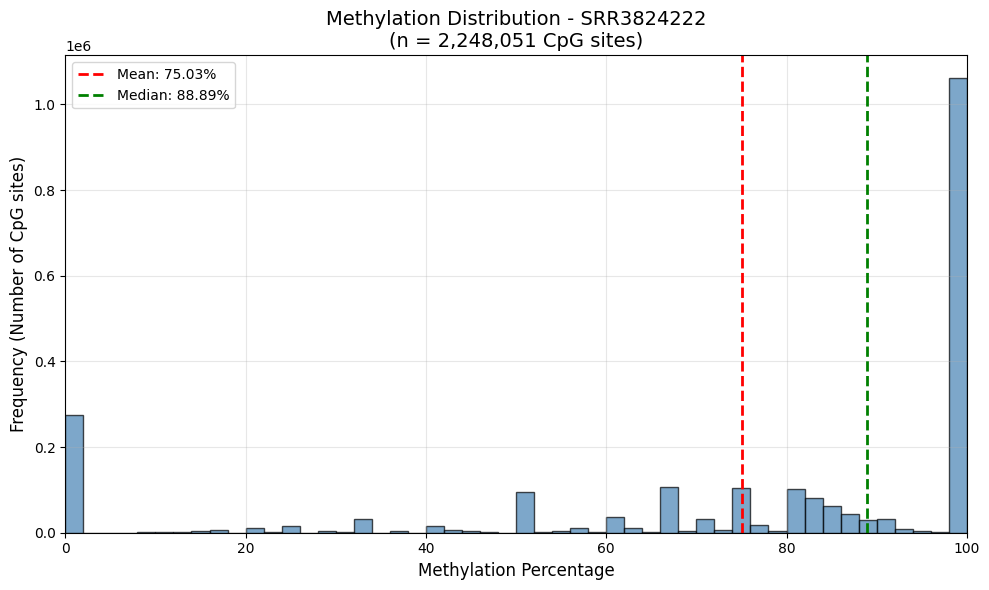


SRR3824222 Summary:
  Total CpG sites: 2,248,051
  Mean methylation: 75.03%
  Median methylation: 88.89%
  % methylated (>50%): 78.6%
  % unmethylated (<50%): 17.2%
--------------------------------------------------
Processing SRR5836473...


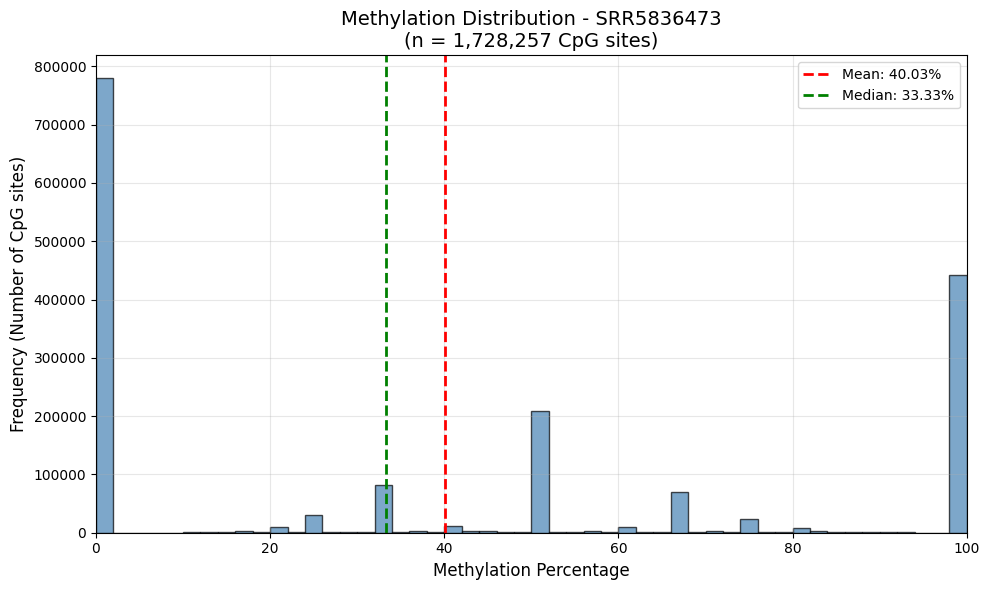


SRR5836473 Summary:
  Total CpG sites: 1,728,257
  Mean methylation: 40.03%
  Median methylation: 33.33%
  % methylated (>50%): 33.6%
  % unmethylated (<50%): 54.4%
--------------------------------------------------
Processing SRR5836475...


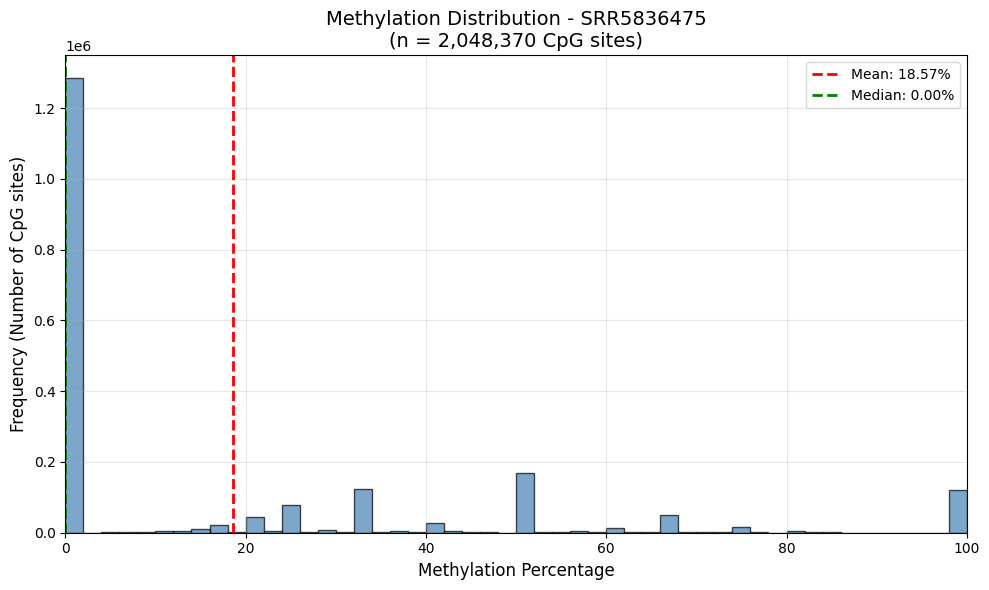


SRR5836475 Summary:
  Total CpG sites: 2,048,370
  Mean methylation: 18.57%
  Median methylation: 0.00%
  % methylated (>50%): 11.2%
  % unmethylated (<50%): 80.6%
--------------------------------------------------


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import gzip
import numpy as np
import io
from pathlib import Path

def plot_methylation_histogram(bedgraph_gz_file, sample_name):
    print(f"Processing {sample_name}...")
    with gzip.open(bedgraph_gz_file, 'rt') as f:
        lines = [line for line in f if not line.startswith(('track', 'browser'))]
    
    df = pd.read_csv(io.StringIO(''.join(lines)), sep='\t', header=None)
    methylation = df[3].values
    methylation = methylation[(methylation >= 0) & (methylation <= 100)]
    
    mean_meth = methylation.mean()
    median_meth = np.median(methylation)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    counts, bins, patches = ax.hist(methylation, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    
    ax.axvline(mean_meth, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_meth:.2f}%')
    ax.axvline(median_meth, color='green', linestyle='--', linewidth=2, label=f'Median: {median_meth:.2f}%')
    
    ax.set_title(f'Methylation Distribution - {sample_name}\n(n = {len(methylation):,} CpG sites)', fontsize=14)
    ax.set_xlabel('Methylation Percentage', fontsize=12)
    ax.set_ylabel('Frequency (Number of CpG sites)', fontsize=12)
    ax.set_xlim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(f'{sample_name}_methylation_histogram.png', dpi=150)
    plt.show()
    
    print(f"\n{sample_name} Summary:")
    print(f"  Total CpG sites: {len(methylation):,}")
    print(f"  Mean methylation: {mean_meth:.2f}%")
    print(f"  Median methylation: {median_meth:.2f}%")
    print(f"  % methylated (>50%): {(methylation > 50).mean()*100:.1f}%")
    print(f"  % unmethylated (<50%): {(methylation < 50).mean()*100:.1f}%")
    print("-" * 50)

bedgraph_files = list(Path("wgbs_tutorial/methylation").glob("*.bedGraph.gz"))
for bf in bedgraph_files:
    sample_name = bf.name.replace("_1_bismark_bt2_pe_namesorted.deduplicated.bedGraph.gz", "")
    sample_name = sample_name.replace("_1_bismark_bt2_pe_namesorted.deduplicated", "")
    plot_methylation_histogram(str(bf), sample_name)

На основе выведенных данных можно сделать следующие наблюдения и выводы:
- На стадии 8-cell 54.4% CpG-сайтов практически неметилированы (<50%), а 33.6% высоко метилированы
- На стадии ICM неметилированы аж 80.6% CpG-сайтов, а метилированы только 11.2%
- На стадии Epiblast высоко метилированы уже 78.6%, и лишь 17.2% остаются недометилированными

Таким образом, гистограммы чётко демонстрируют две ключевые волны ремоделирования метилома: сначала (8-cell -> ICM) происходит глобальное деметилирование до уровня 11.2%, а затем (ICM -> Epiblast) повторное метилирование до уровня 78.6%. Также нечётко, но прослеживается бимодальный характер распределения: CpG-островки остаются защищёнными, а остальной геном активно метилируется.

## Часть 2

Проводим визуализацию при помощи pyGenomeTracks.

In [30]:
! pyGenomeTracks --tracks tracks.ini --region chr11:4,000,000-4,200,000 --outFile methylation_region.png

INFO:pygenometracks.tracksClass:initialize 1. [x-axis]
INFO:pygenometracks.tracksClass:initialize 2. [spacer]
INFO:pygenometracks.tracksClass:initialize 3. [genes]
100%|█████████████████████████████████████████| 68/68 [00:00<00:00, 5677.68it/s]
INFO:pygenometracks.tracksClass:initialize 4. [spacer]
INFO:pygenometracks.tracksClass:initialize 5. [coverage_SRR3824222]
Will use default.

100%|████████████████████████████████████| 5127/5127 [00:00<00:00, 99595.66it/s]
INFO:pygenometracks.tracksClass:initialize 6. [coverage_SRR5836475]
Will use default.

100%|████████████████████████████████████| 4805/4805 [00:00<00:00, 97739.69it/s]
INFO:pygenometracks.tracksClass:initialize 7. [coverage_SRR5836473]
Will use default.

100%|███████████████████████████████████| 4282/4282 [00:00<00:00, 101926.21it/s]
INFO:pygenometracks.tracksClass:time initializing track(s):
INFO:pygenometracks.tracksClass:2.672623872756958
DEBUG:pygenometracks.tracksClass:Figure size in cm is 40 x 23.72340425531915. Dpi is s

Получаем следующий график:

![alt-text](images/methylation_region.png)

Визуализация подтверждает выводы о двухволновой структуре процесса: сначала уровень метилирования снижается, а потом резко повышается.

## Часть 3

Займёмся DMR и DMC. Я выбрал метод metilene, поскольку он учитывает биноминальное распределение метилирования и позволяет настроить все необходимые параметры.

Параметры для DMC:
- `-f 1`: небольшой порог на минимальное покрытие, чтобы выявить больше образцов для дальнейшего анализа

Параметры для DMR:
- `-M 300`: объединяем CpG в один DMR, если расстояние между ними не превышает 300 пар оснований (стандартное значение)

- `-m 10`: DMR должен содержать не менее 10 CpG‑сайтов (повышает биологическую значимость и снижает ложные срабатывания)

- `-d 0.2`: минимальная разница среднего уровня метилирования между группами 20%  (соответствует клинически значимым изменениям)

- `-f 1`: небольшой порог на минимальное покрытие, чтобы выявить больше образцов для дальнейшего анализа

Я сравнивал Epiblast (SRR3824222) и 8cell (SRR5836473) как конечную и начальную стадии.

In [ ]:
%%bash
mkdir -p wgbs_tutorial/metilene
cd wgbs_tutorial/metilene
cp ../methylation/*.bedGraph.gz .
gunzip *.bedGraph.gz 

In [14]:
%%bash
cd wgbs_tutorial/metilene
bedtools unionbedg -i \
    SRR3824222_1_bismark_bt2_pe_namesorted.deduplicated.bedGraph \
    SRR5836475_1_bismark_bt2_pe_namesorted.deduplicated.bedGraph \
    SRR5836473_1_bismark_bt2_pe_namesorted.deduplicated.bedGraph \
    > all_samples.bedgraph
head -5 all_samples.bedgraph

chr11	3050030	3050031	75	33.3333333333333	50
chr11	3050031	3050032	100	50	0
chr11	3050047	3050048	100	50	66.6666666666667
chr11	3050048	3050049	100	66.6666666666667	0
chr11	3050223	3050224	96.875	36.3636363636364	87.5


In [15]:
%%bash
cd wgbs_tutorial/metilene
awk -v OFS='\t' '{print $1, $2, $4, $6}' all_samples.bedgraph > metilene_input_raw.txt
head -5 metilene_input_raw.txt

chr11	3050030	75	50
chr11	3050031	100	0
chr11	3050047	100	66.6666666666667
chr11	3050048	100	0
chr11	3050223	96.875	87.5


In [16]:
%%bash
cd wgbs_tutorial/metilene
sort -V -k1,1 -k2,2n metilene_input_raw.txt > metilene_input_sorted.txt
head -5 metilene_input_sorted.txt

chr11	3050030	75	50
chr11	3050031	100	0
chr11	3050047	100	66.6666666666667
chr11	3050048	100	0
chr11	3050223	96.875	87.5


In [17]:
%%bash
cd wgbs_tutorial/metilene
echo -e "chr\tpos\tg1_1\tg2_1" > metilene_input_with_header.txt
cat metilene_input_sorted.txt >> metilene_input_with_header.txt
head -5 metilene_input_with_header.txt

chr	pos	g1_1	g2_1
chr11	3050030	75	50
chr11	3050031	100	0
chr11	3050047	100	66.6666666666667
chr11	3050048	100	0


In [18]:
%%bash
cd wgbs_tutorial/metilene
metilene -f 1 -a g1 -b g2 -t 4 metilene_input_with_header.txt > DMC_output.txt 2>/dev/null
head -5 DMC_output.txt

chr11	3060321	3060544	1	46.344655	10	1.0825e-05	0.00012693	64.313	17.968
chr11	3070605	3071247	1	61.879252	14	0.00011357	3.8845e-05	74.974	13.095
chr11	3079452	3080185	0.82707	44.366316	25	1.3329e-09	5.893e-06	93.144	48.777
chr11	3081786	3082592	1.7883e-05	35.560730	30	2.8764e-11	1.2742e-10	92.577	57.017
chr11	3089575	3089704	1	58.476337	12	7.396e-07	0.0010372	81.761	23.285


In [19]:
%%bash
cd wgbs_tutorial/metilene
metilene -f 1 -M 300 -m 10 -d 0.2 -a g1 -b g2 -t 4 metilene_input_with_header.txt > DMR_output.txt 2>/dev/null
head -5 DMR_output.txt

chr11	3060321	3060544	1	46.344655	10	1.0825e-05	0.00012693	64.313	17.968
chr11	3070605	3071247	1	61.879252	14	0.00011357	3.8845e-05	74.974	13.095
chr11	3079452	3080185	0.82707	44.366316	25	1.3329e-09	5.893e-06	93.144	48.777
chr11	3081786	3082592	1.7883e-05	35.560730	30	2.8764e-11	1.2742e-10	92.577	57.017
chr11	3089575	3089704	1	58.476337	12	7.396e-07	0.0010372	81.761	23.285


In [20]:
%%bash
cd wgbs_tutorial/metilene
awk '$4 < 0.05 && $6 >= 10 && ($5 >= 0.2 || $5 <= -0.2)' DMR_output.txt > DMR_significant.txt
head -5 DMR_significant.txt

chr11	3081786	3082592	1.7883e-05	35.560730	30	2.8764e-11	1.2742e-10	92.577	57.017
chr11	3099966	3100517	0.00010244	48.600568	37	2.29e-10	7.2988e-10	91.111	42.51
chr11	3114671	3115134	0.044294	52.290879	15	3.067e-06	3.156e-07	85.716	33.425
chr11	3141998	3143011	3.9474e-05	52.265085	36	1.3676e-10	2.8126e-10	70.616	18.351
chr11	3198752	3200569	1.1097e-05	76.306548	40	8.0203e-13	7.9065e-11	92.205	15.899


In [21]:
! echo "DMC (все):" && wc -l wgbs_tutorial/metilene/DMC_output.txt
! echo "DMR (значимые):" && wc -l wgbs_tutorial/metilene/DMR_significant.txt

DMC (все):
27060 wgbs_tutorial/metilene/DMC_output.txt


DMR (значимые):
4744 wgbs_tutorial/metilene/DMR_significant.txt


Обнаружено более 27000 дифференциально метилированных цитозинов и 4744 значимых дифференциально метилированных региона между эпибластом и 8-клеточным эмбрионом. Это отражает масштабные изменения метилирования ДНК, происходящие в ходе раннего эмбрионального развития мыши.

## Дополнительная часть

Для начала при помощи Python создадим файл `genes_in_DMR.txt`, в который сохраним список генов, промоторы которых перекрываются с дифференциально метилированными регионами (DMR), найденными на предыдущем этапе.

In [ ]:
import pandas as pd
import numpy as np

dmr = pd.read_csv("wgbs_tutorial/metilene/DMR_significant.txt", sep='\t', header=None)
dmr = dmr.iloc[:, [0, 1, 2]]
dmr.columns = ['chrom', 'start', 'end']
dmr['chrom'] = dmr['chrom'].astype(str).str.replace('chr', '')
dmr.to_csv('dmr.bed', sep='\t', header=False, index=False)

gtf = pd.read_csv("Mus_musculus.GRCm39.112.gtf", sep='\t', comment='#', header=None, low_memory=False)
gtf.columns = ['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']
genes = gtf[gtf['feature'] == 'gene'].copy()

genes['gene_name'] = genes['attribute'].str.extract('gene_name "([^"]+)"')
genes = genes.dropna(subset=['gene_name'])

def get_promoter(row):
    if row['strand'] == '+':
        return pd.Series([row['start'] - 1000, row['start'] + 500])
    else:
        return pd.Series([row['end'] - 500, row['end'] + 1000])

genes[['prom_start', 'prom_end']] = genes.apply(get_promoter, axis=1)
genes['prom_start'] = genes['prom_start'].astype(int).clip(lower=0)
genes['prom_end'] = genes['prom_end'].astype(int)
genes = genes[genes['prom_start'] < genes['prom_end']]

promoters = genes[['seqname', 'prom_start', 'prom_end', 'gene_name']]
promoters.to_csv('promoters.bed', sep='\t', header=False, index=False)

!bedtools intersect -a dmr.bed -b promoters.bed -wa -wb > dmr_genes_overlap.txt

overlap_df = pd.read_csv("dmr_genes_overlap.txt", sep='\t', header=None)
genes_in_dmr = overlap_df.iloc[:, 6].unique()

print(f"Найдено генов: {len(genes_in_dmr)}")

with open('genes_in_DMR.txt', 'w') as f:
    for gene in genes_in_dmr:
        f.write(str(gene) + '\n')

Найдено генов: 351


Теперь полученный список из 351 гена загружаем на сайт https://biit.cs.ut.ee/gprofiler/gost и анализируем. Получаем вот такой результат:

![alt text](images/go.png)

Из 339 генов, чьи промоторы пересекаются с значимыми DMR, всего выделено 6 терминов, из которых высокой значимостью обладают лишь два:
- `intermediate filament organization` (GO:0045109, p-adj = 2.244e-9)
- `intermediate filament` (GO:0005882, p-adj = 7.376e-8)

Они отвечают за промежуточные филаменты, т.е. в DMR чаще всего попадают гены, отвественные за строительство/перестройку скелета. Это согласуется со здравым смыслом.

Оставшиеся термины связаны с общей организацией клеточных структур и цитоплазмой, однако имеют относительно низкую значимость.

График это подтверждает: все значимые термины находятся в категориях GO:BP (biological process) и GO:CC (cellular component).